# Importing Required Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, roc_auc_score, confusion_matrix, precision_recall_curve
from xgboost import XGBClassifier

### 2. Data Preprocessing & 70-20-10 Split
We define a reproducible data pipeline. We use a **70-20-10 split** strategy:
* **70% Training:** Used for model weight optimization.
* **20% Validation:** Used for tuning hyperparameters and early stopping.
* **10% Test:** A "held-out" set for final unbiased performance assessment.
*Stratification* is applied to the target variable (`Class`) to ensure the minority fraud cases are proportionally represented in all three subsets.

In [22]:
df = pd.read_csv('creditcard.csv').dropna()


train_df, temp = train_test_split(df, test_size=0.3, stratify=df['Class'], random_state=42)
val_df, test_df = train_test_split(temp, test_size=0.33, stratify=temp['Class'], random_state=42)

X_train, y_train = train_df.drop('Class', axis=1), train_df['Class']
X_val, y_val = val_df.drop('Class', axis=1), val_df['Class']
X_test, y_test = test_df.drop('Class', axis=1), test_df['Class']

### 3. Model Training & Regularization Experiment
Here, we perform a comparative study between an **Unregularized** model (baseline) and a **Regularized** model. 
* **L1 (alpha)** and **L2 (lambda)** regularization are applied to the second model to penalize model complexity and prevent overfitting to noise in the training set.
* **Early Stopping** is monitored on the validation set to ensure we stop training at the peak of generalization.

In [8]:
weight = (y_train == 0).sum() / (y_train == 1).sum()

# Unregularized Model
model_unreg = XGBClassifier(scale_pos_weight=weight, reg_alpha=0, reg_lambda=0, n_estimators=200, random_state=42, eval_metric="logloss")
model_unreg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)

# Regularized Model
model_reg = XGBClassifier(scale_pos_weight=weight, reg_alpha=0.1, reg_lambda=1.0, n_estimators=200, random_state=42, eval_metric="logloss")
model_reg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


### 4. Quantitative Performance Report
We evaluate the models using the **F1-Score**. In fraud detection, where the target class is highly imbalanced, Accuracy is a deceptive metric. The F1-Score provides a balanced view of both Precision (avoiding false alarms) and Recall (detecting as much fraud as possible).

In [9]:


# Predictions
y_pred_unreg = model_unreg.predict(X_test)
y_pred_reg = model_reg.predict(X_test)

# Compare F1-Scores
results = pd.DataFrame({
    'Model': ['Unregularized', 'Regularized'],
    'F1-Score': [f1_score(y_test, y_pred_unreg), f1_score(y_test, y_pred_reg)]
})

print(results)

           Model  F1-Score
0  Unregularized  0.869565
1    Regularized  0.851064


### 5. Diagnostic Visualization & Interpretability
This block visualizes the model's behavior:
1. **Loss Curves:** We monitor the training vs. validation loss. If the validation loss begins to diverge from training loss, it indicates overfitting.
2. **Precision-Recall Curve:** This represents the trade-off between capturing fraud cases and maintaining high precision.
3. **Feature Importance:** We identify the top 10 variables driving the model’s decisions, allowing us to explain "Why" the model flagged a specific transaction.

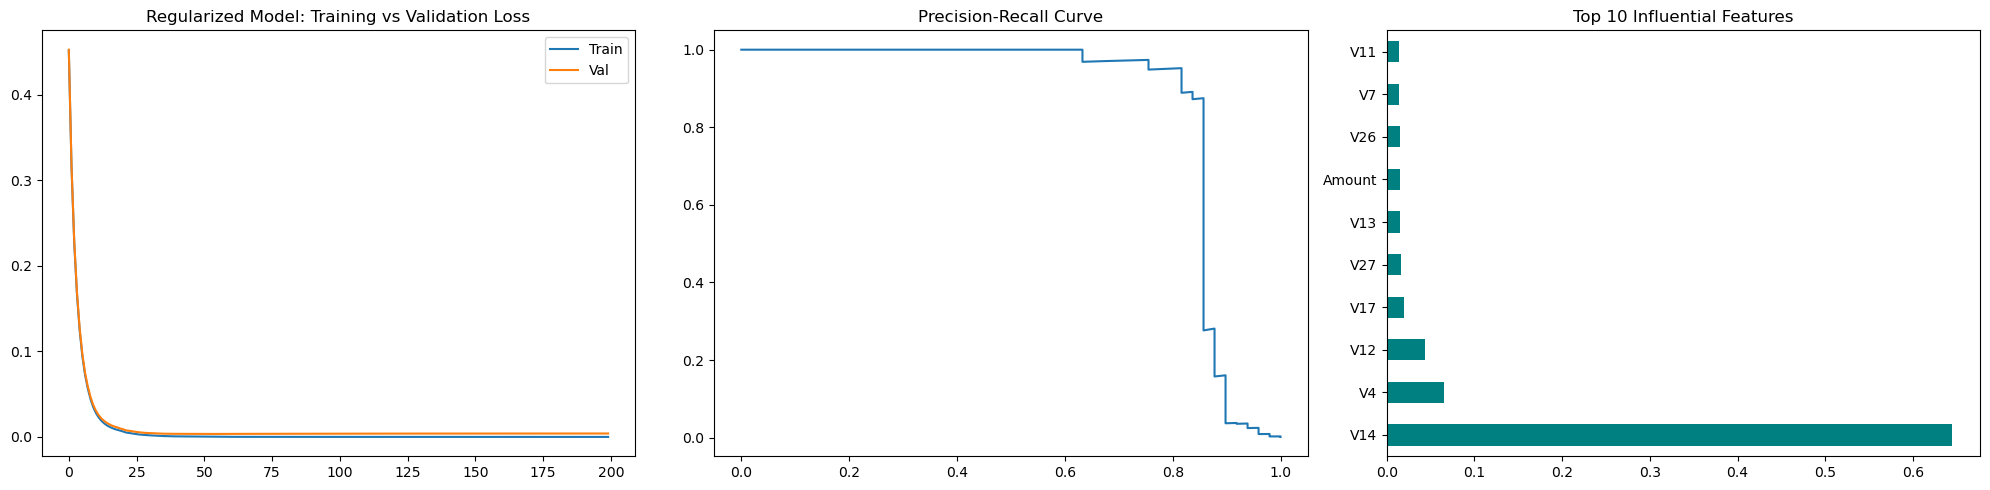

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Loss Curves
results_reg = model_reg.evals_result()
axes[0].plot(results_reg['validation_0']['logloss'], label='Train')
axes[0].plot(results_reg['validation_1']['logloss'], label='Val')
axes[0].set_title('Regularized Model: Training vs Validation Loss')
axes[0].legend()

# 2. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, model_reg.predict_proba(X_test)[:,1])
axes[1].plot(recall, precision)
axes[1].set_title('Precision-Recall Curve')

# 3. Feature Importance
feat_imp = pd.Series(model_reg.feature_importances_, index=X_train.columns)
feat_imp.nlargest(10).plot(kind='barh', ax=axes[2], color='teal')
axes[2].set_title('Top 10 Influential Features')

plt.tight_layout()
plt.show()

### 6. Model Inference: Random Sample Validation
To validate our model's performance on real-world inputs, we select 10 random data points from the test set. The table below compares the model's **Predicted** fraud status against the **Actual** ground truth labels, demonstrating the model's capability to generalize on unseen transaction data.

In [23]:

# Identify indices of actual fraudulent cases in our test set
fraud_indices = y_test[y_test == 1].index

# If there are fraud cases, pick a few; otherwise warn
if len(fraud_indices) > 0:
    # Select up to 10 fraud cases (or all if fewer than 10)
    sample_size = min(10, len(fraud_indices))
    sample_indices = np.random.choice(fraud_indices, sample_size, replace=False)
    
    sample_data = X_test.loc[sample_indices]
    actual_values = y_test.loc[sample_indices]
    
    # Get predictions
    predictions = model_reg.predict(sample_data)
    
    # Create and display results table
    inference_table = pd.DataFrame({
        'Actual': actual_values, 
        'Predicted': predictions
    })
    
    print("--- Performance on Rare Fraud Cases ---")
    print(inference_table)
else:
    print("No fraud cases found in the current test subset.")

--- Performance on Rare Fraud Cases ---
        Actual  Predicted
8312         1          1
27749        1          1
141260       1          1
124115       1          1
15810        1          1
153835       1          1
204064       1          1
234633       1          1
254395       1          0
181966       1          1
